In [1]:
import yaml
import numpy as np
import polars as pl
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000244734""","""mean_corpuscular_haemoglobin_i…",5.8426e-107,-0.414609,0.414609,-1.0
"""ENSG00000188536""","""mean_corpuscular_haemoglobin_i…",4.2593e-22,-0.366514,0.366514,-1.0
"""ENSG00000101439""","""cystatin_c_int""",9.0570e-172,-0.364046,0.364046,-1.0
"""ENSG00000149948""","""standing_height_int""",0.035047,-0.302164,0.302164,-1.0
"""ENSG00000205846""","""aspartate_aminotransferase_int""",0.049103,0.298817,0.298817,1.0
…,…,…,…,…,…
"""ENSG00000104408""","""mean_corpuscular_volume_int""",0.003124,-0.005248,0.005248,-1.0
"""ENSG00000162992""","""glycated_haemoglobin_hba1c_int""",0.000525,0.004895,0.004895,1.0
"""ENSG00000134030""","""leg_fat_percentage_right_int""",0.028495,0.003606,0.003606,1.0


In [3]:
# Configuration and paths
mac = 20

# Initialize new annotation variable as None
new_anno_local = None
keep_fillna = True

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds.yaml"

with open(config_path) as f:
    config = yaml.safe_load(f)

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""missense""","""am_pathogenicity""","""#FFCA28""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#FB8C00""","""ESM1v""",-1
"""missense""","""score_pai3d""","""#D84315""","""PrimateAI-3D""",1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_score""","""pink""","""GPN-MSA""",-1
…,…,…,…,…
"""regulatory""","""fz_all_mean""","""#1f77b4""","""Flashzoi mean across RNA (all)""",1
"""regulatory""","""fz_blood_min""","""crimson""","""Flashzoi min across RNA (blood…",-1
"""regulatory""","""fz_all_min""","""#FFA500""","""Flashzoi min across RNA (all)""",-1


In [4]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym.parquet"
ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

anno = (
    anno
    .filter(
        # Filter to gene regions of interest
        (pl.col('region').is_in(gene_trait_df['region'].unique())),
        
        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)),

        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True),

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)),

        # Choose VEP consequence
        (pl.col('consequence_missense_variant') == True),

        # Choose protein domain
        # (pl.col('ted_domain') == True),
        # (pl.col('mobi_lip_full') == True),
        # (pl.col('ted_domain') == False),
        # (pl.col('mobi_curated_disorder_priority') == True),

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .with_columns(
        loftee_disorder = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_curated_disorder_priority']),
        loftee_lip = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_lip_full']),
        loftee_ted = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'ted_domain']),
        loftee_low_complexity = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'low_complexity_domain']),
    )
)


selected_categories = ['missense'] # missense

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

Error: path
"/home/dnanexus/data_dir/annotations_fillna_ukbgym_with_mane.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_46769/129553571.py:52: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_46769/129553571.py:61: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


region,am_pathogenicity,score_pai3d,esmscoremissense,id
str,f32,f32,f32,str
"""ENSG00000155657""",0.3975,0.0,-4.66,"""chr2:178795028:T:C"""
"""ENSG00000184999""",0.1285,0.541813,-7.895,"""chr11:63290536:A:C"""
"""ENSG00000135956""",0.996,0.8291,-6.354,"""chr2:96265270:C:G"""
"""ENSG00000205189""",0.506,0.0,-3.546,"""chr8:80487528:A:G"""
"""ENSG00000143382""",0.0772,0.308568,-5.567,"""chr1:150557191:C:T"""
…,…,…,…,…
"""ENSG00000132693""",0.2634,0.533682,-7.537,"""chr1:159713719:C:T"""
"""ENSG00000174282""",0.0816,0.0,-3.264,"""chr17:7462167:T:C"""
"""ENSG00000049323""",0.3573,0.0,-2.908,"""chr2:32948891:G:A"""


In [5]:
anno_fillna = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
fillna_cols = set([c+'_is_na' for c in selected_annos]).intersection(set(anno_fillna.collect_schema().names()))

anno_fillna_melted = (
    anno_fillna
    .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
    .select(['id', 'region'] + list(fillna_cols))
    .join(
        anno.select(['id', 'region']).lazy(), 
        on=['id', 'region'], 
        how='semi'
    )
    .unpivot(
        index=["id", "region"],
        on=list(fillna_cols),
        variable_name="annotation",
        value_name="annotation_is_na"
    )
    .filter(
        pl.col('annotation_is_na') == 1
    )
    .with_columns(
        annotation = pl.col('annotation').str.replace('_is_na$', '')
    )
)

anno_fillna_melted.head().collect()

/tmp/ipykernel_46769/2928459309.py:27: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_is_na
str,str,str,i8
"""chr8:108268347:T:C""","""ENSG00000104408""","""esmscoremissense""",1
"""chr2:71276645:C:T""","""ENSG00000075292""","""esmscoremissense""",1
"""chr2:71276708:G:A""","""ENSG00000075292""","""esmscoremissense""",1
"""chr8:108268329:T:C""","""ENSG00000104408""","""esmscoremissense""",1
"""chr1:58473895:T:C""","""ENSG00000162600""","""esmscoremissense""",1


In [6]:
melted_anno = (
    anno.lazy()

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]).lazy(),
        on="annotation",
        how="left"
    )
    .filter(pl.col('category').is_in(selected_categories))
    .unique()

    # Remove null annotation scores
    .drop_nulls('annotation_score')

    # Keep variants that don't have fillna annotation (skip if keep_fillna=True)
    .pipe(lambda df: df if keep_fillna else df.join(
        anno_fillna_melted,
        on=['id', 'region', 'annotation'],
        how='anti'
    ))

    # Correct scores by annotation direction
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Rank variants (descending direction-corrected score)
    .with_columns(
        annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="max", descending=True).over(["annotation"]).cast(pl.Float32)
    )
    .drop(['annotation_score_dircor'])

    .collect(engine='streaming')
)

melted_anno

id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_rank_desc
str,str,str,f32,str,i8,f32
"""chr14:67766268:G:C""","""ENSG00000072121""","""score_pai3d""",0.802869,"""missense""",1,45697.0
"""chr8:25368666:A:G""","""ENSG00000147459""","""score_pai3d""",0.747539,"""missense""",1,67360.0
"""chr14:54702158:A:C""","""ENSG00000020577""","""score_pai3d""",0.0,"""missense""",1,380229.0
"""chr7:100688090:C:T""","""ENSG00000146830""","""score_pai3d""",0.0,"""missense""",1,380229.0
"""chr9:122897305:C:A""","""ENSG00000056586""","""score_pai3d""",0.736713,"""missense""",1,71712.0
…,…,…,…,…,…,…
"""chr12:21202664:G:A""","""ENSG00000134538""","""score_pai3d""",0.88741,"""missense""",1,17610.0
"""chr1:114618394:G:A""","""ENSG00000175984""","""score_pai3d""",0.0,"""missense""",1,380229.0
"""chr22:50462406:C:T""","""ENSG00000100241""","""score_pai3d""",0.646786,"""missense""",1,108162.0


In [7]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

APPV_FILE = "quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
pheno_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Filter to variants in annotation set and low MAC
anno_keys = anno.select(pl.col('id').unique()).lazy()

pheno_appv = (
    pheno_appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)

[===========================================================>] Completed 872,915,124 of 872,915,124 bytes (100%) /home/dnanexus/data_dir/quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquett


In [8]:
pheno_appv.head().collect()

id,phenotype,mean_pheno_value,n_individuals
str,str,f32,i32
"""chr2:178571014:C:T""","""leg_fatfree_mass_left_int""",-0.04929,7
"""chr17:50187944:C:T""","""basal_metabolic_rate_int""",0.992802,3
"""chr2:178741274:T:C""","""seated_height_int""",0.461834,9
"""chr15:58893289:C:A""","""arm_fat_mass_right_int""",0.632569,1
"""chr2:203125973:G:C""","""seated_height_int""",0.39507,12


## Average z-score by annotation rank (sliding window)

In [9]:
# Sliding window parameters
window_size = 1_000  # Number of variants in the sliding window
step_size = 1_0      # Step between sampled points (controls plot smoothness)

In [10]:
# --- Join variant z-scores with annotation ranks, then apply sliding window ---

id_region = anno.select(['id', 'region']).unique().lazy()

# Get variant-level z-scores joined with pheno whitelist
# Direction-correct mean_pheno_value: if loftee_corr_dir == -1, flip the z-score
# so that "deleterious" variants always have positive z-scores
variant_zscores = (
    pheno_appv
    .join(id_region, on='id', how='inner')
    .join(gene_trait_df.lazy(), on=['region', 'phenotype'], how='inner')
    .with_columns(
        mean_pheno_value = pl.col('mean_pheno_value') * pl.col('loftee_corr_dir').cast(pl.Float32)
    )
    .select(['id', 'region', 'mean_pheno_value'])
    .collect(engine='streaming')
)

print(f"Variant z-scores: {variant_zscores.shape[0]} variant-gene pairs")

half_w = window_size // 2

# Sliding window over row position (not rank values) to guarantee window_size variants per window.
# Sorted by rank within annotation, row_pos = sequential index = "Top N variants".
# rolling_mean/std with min_samples=window_size ensures only full windows are kept.
zscore_binned = (
    variant_zscores.lazy()
    .join(
        melted_anno.lazy().select(['id', 'region', 'annotation', 'annotation_score_dircor_rank_desc']),
        on=['id', 'region'],
        how='inner'
    )
    .sort(['annotation', 'annotation_score_dircor_rank_desc'])
    .with_columns(
        row_pos = pl.col('annotation').cum_count().over('annotation'),
    )
    .with_columns(
        mean_zscore = pl.col('mean_pheno_value')
            .rolling_mean(window_size=window_size, min_samples=window_size, center=True)
            .over('annotation'),
        sd_zscore = pl.col('mean_pheno_value')
            .rolling_std(window_size=window_size, min_samples=window_size, center=True)
            .over('annotation'),
    )
    # Sample at window centers: first center at half_w, then every step_size
    .filter(
        ((pl.col('row_pos') - half_w) % step_size == 0)
    )
    .drop_nulls('mean_zscore')
    .with_columns(
        bin_center = pl.col('row_pos').cast(pl.Float64),
        se_zscore = pl.col('sd_zscore') / (window_size ** 0.5),
    )
    .with_columns(
        ci_lower = pl.col('mean_zscore') - 1.96 * pl.col('se_zscore'),
        ci_upper = pl.col('mean_zscore') + 1.96 * pl.col('se_zscore'),
    )
    .select(['annotation', 'bin_center', 'mean_zscore', 'sd_zscore', 'se_zscore', 'ci_lower', 'ci_upper'])
    .sort(['annotation', 'bin_center'])
    .collect()
)

print(f"Sliding window results: {zscore_binned.shape[0]} points across {zscore_binned['annotation'].n_unique()} annotations")
zscore_binned

Variant z-scores: 339915 variant-gene pairs
Sliding window results: 101673 points across 3 annotations


annotation,bin_center,mean_zscore,sd_zscore,se_zscore,ci_lower,ci_upper
str,f64,f32,f32,f32,f32,f32
"""am_pathogenicity""",510.0,0.29005,0.983949,0.031115,0.229065,0.351036
"""am_pathogenicity""",520.0,0.290399,0.982177,0.031059,0.229523,0.351274
"""am_pathogenicity""",530.0,0.284745,0.981425,0.031035,0.223915,0.345574
"""am_pathogenicity""",540.0,0.277306,0.978177,0.030933,0.216678,0.337934
"""am_pathogenicity""",550.0,0.276631,0.977222,0.030902,0.216062,0.3372
…,…,…,…,…,…,…
"""score_pai3d""",339370.0,0.064123,0.887787,0.028074,0.009097,0.119148
"""score_pai3d""",339380.0,0.067422,0.890211,0.028151,0.012246,0.122597
"""score_pai3d""",339390.0,0.062883,0.8915,0.028192,0.007627,0.118139


## Plotting

In [11]:
plt_df = (
    zscore_binned
    .drop_nans()
    .with_columns(
        log_bin_center = pl.col('bin_center').log10(),
        log_bin_center_inv = (1 / pl.col('bin_center')).log10(),
    )
    .join(
        anno_config_df.filter(pl.col('category').is_in(selected_categories)).select(['annotation', 'color', 'label', 'category']).unique(),
        on='annotation',
        how='left'
    )
    .filter(pl.col('category').is_in(selected_categories))
    .sort('bin_center')
)

plt_df

annotation,bin_center,mean_zscore,sd_zscore,se_zscore,ci_lower,ci_upper,log_bin_center,log_bin_center_inv,color,label,category
str,f64,f32,f32,f32,f32,f32,f64,f64,str,str,str
"""am_pathogenicity""",510.0,0.29005,0.983949,0.031115,0.229065,0.351036,2.70757,-2.70757,"""#FFCA28""","""AlphaMissense""","""missense"""
"""esmscoremissense""",510.0,0.393208,0.997176,0.031533,0.331402,0.455014,2.70757,-2.70757,"""#FB8C00""","""ESM1v""","""missense"""
"""score_pai3d""",510.0,0.299615,1.056593,0.033412,0.234127,0.365103,2.70757,-2.70757,"""#D84315""","""PrimateAI-3D""","""missense"""
"""am_pathogenicity""",520.0,0.290399,0.982177,0.031059,0.229523,0.351274,2.716003,-2.716003,"""#FFCA28""","""AlphaMissense""","""missense"""
"""esmscoremissense""",520.0,0.397057,0.996673,0.031518,0.335283,0.458832,2.716003,-2.716003,"""#FB8C00""","""ESM1v""","""missense"""
…,…,…,…,…,…,…,…,…,…,…,…
"""esmscoremissense""",339400.0,-0.011065,0.8182,0.025874,-0.061778,0.039647,5.530712,-5.530712,"""#FB8C00""","""ESM1v""","""missense"""
"""score_pai3d""",339400.0,0.064684,0.892502,0.028223,0.009366,0.120002,5.530712,-5.530712,"""#D84315""","""PrimateAI-3D""","""missense"""
"""am_pathogenicity""",339410.0,0.028875,0.805258,0.025464,-0.021036,0.078785,5.530725,-5.530725,"""#FFCA28""","""AlphaMissense""","""missense"""


In [36]:
# LOFTEE point
loftee_vars = (
    pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
    .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
    .filter(pl.col('loftee_hc')==1)
    .collect(engine='streaming')
)

id_region = loftee_vars.select(['id', 'region']).unique().lazy()

# Get variant-level z-scores joined with olink whitelist
loftee_zscores = (
    pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")
    .join(id_region, on='id', how='inner')
    .join(gene_trait_df.lazy(), on=['region', 'phenotype'], how='inner')
    .with_columns(
        mean_pheno_value = pl.col('mean_pheno_value') * pl.col('loftee_corr_dir').cast(pl.Float32)
    )
    .select(['id', 'region', 'mean_pheno_value'])
    .collect(engine='streaming')
)

mean_zscore = loftee_zscores['mean_pheno_value'].mean()
se_zscore = loftee_zscores['mean_pheno_value'].std() / (loftee_zscores.shape[0] ** 0.5)
ci_se_lower = mean_zscore - 1.96 * se_zscore
ci_se_upper = mean_zscore + 1.96 * se_zscore

loftee_point_df = pl.DataFrame({
    'label': 'LOFTEE HC',
    'n_vars': loftee_zscores.shape[0],
    'log_bin_center_inv': np.log10(1 / loftee_zscores.shape[0]),
    'mean_zscore': mean_zscore,
    'se_zscore': se_zscore,
    'ci_se_lower': ci_se_lower,
    'ci_se_upper': ci_se_upper
})

loftee_point = [
    geom_point(loftee_point_df, aes(x='log_bin_center_inv', y='mean_zscore'), size=1),
    geom_errorbar(loftee_point_df, aes(x='log_bin_center_inv', ymin='ci_se_lower', ymax='ci_se_upper'), width=0.01),
    geom_text(loftee_point_df, aes(x='log_bin_center_inv', y='mean_zscore', label='label'), nudge_x=-0.05, size=12, ha='right'),
]

/tmp/ipykernel_46769/1270328231.py:6: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


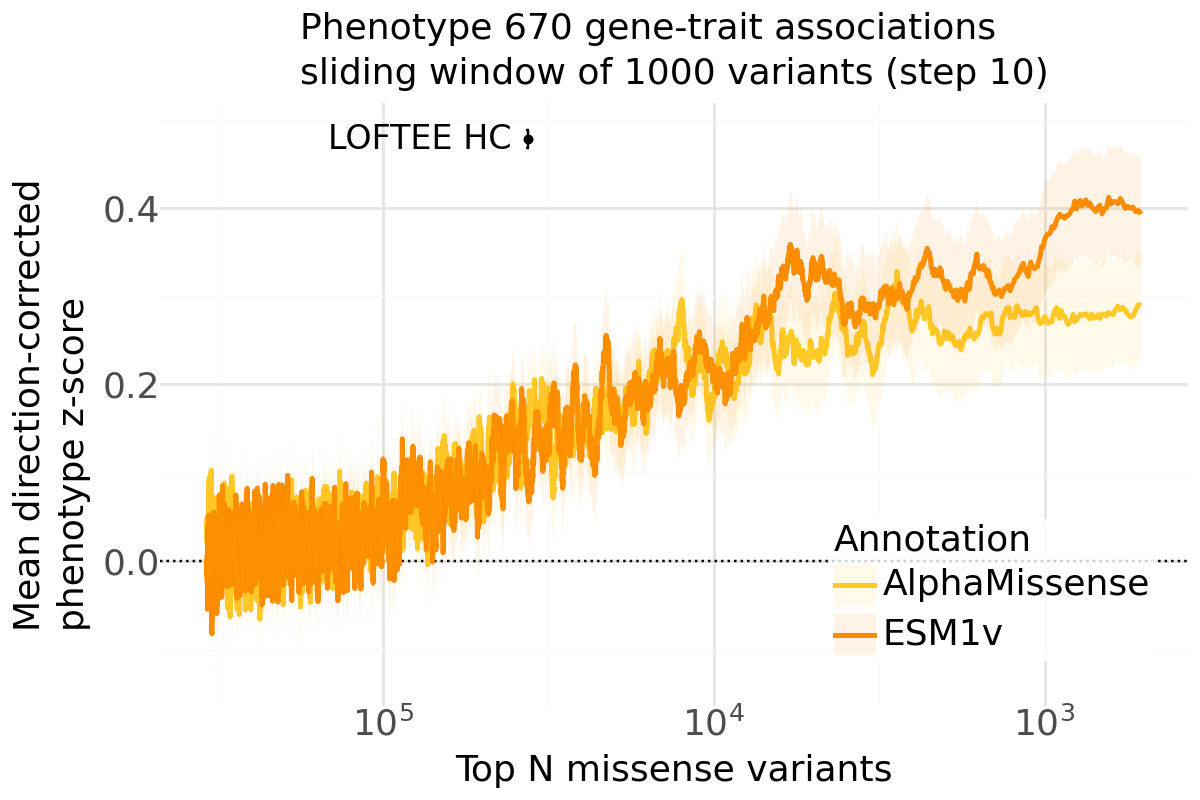

In [37]:
plot_df = (
    plt_df
    .filter(
        (pl.col('annotation').is_in(['am_pathogenicity', 'esmscoremissense']))
    )
)

# Generate breaks and labels for x-axis (same style as odds ratio plot)
max_rank = zscore_binned['bin_center'].max()
min_rank = zscore_binned['bin_center'].min()
start_exp = int(np.floor(np.log10(1/max_rank)))
end_exp = int(np.ceil(np.log10(1/min_rank)))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"$10^{{{int(-b)}}}$" for b in breaks_linear]

color_dict = dict(zip(plt_df['label'], plt_df['color']))

(
    ggplot(
        plot_df,
        aes(x='log_bin_center_inv', y='mean_zscore')
    )
    + loftee_point
    + geom_hline(aes(yintercept=0), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='ci_lower', ymax='ci_upper', fill='label'), alpha=0.1)
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        title=f"Phenotype {gene_trait_df.shape[0]} gene-trait associations\nsliding window of {window_size} variants (step {step_size})",
        y=f"Mean direction-corrected\nphenotype z-score",
        x=f"Top N missense variants",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + theme_minimal()
    + theme(
        figure_size=(6, 4),
        title=element_text(size=13, lineheight=1.4),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_position=(0.95, 0.1),
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)